# Fintech Credit Risk Analytics: LendingClub Loan Portfolio Analysis

**Business objective:** Analyze LendingClub's historical loan portfolio (2014–2018) to
identify the key drivers of borrower default, evaluate whether the platform's own risk
grading is well-calibrated, and compare accepted vs. rejected applicants to understand
approval criteria.

**Author:** Nikhil Pallam
**Dataset:** [LendingClub Loan Data (Kaggle)](https://www.kaggle.com/datasets/wordsforthewise/lending-club)
**Scope:** Data analyst / business analyst portfolio project — deliberately focused on
business-driven analysis and clear visual storytelling, not predictive modeling.

## Phase 0: Setup & Data Loading

Loading the raw accepted-loans file and confirming its structure before doing any
processing.

In [2]:
!ls -lh /content/

total 619M
-rw-r--r-- 1 root root 375M Sep 11 10:29 accepted_2007_to_2018Q4.csv.gz
-rw-r--r-- 1 root root 244M Sep 11 10:34 rejected_2007_to_2018Q4.csv.gz
drwxr-xr-x 1 root root 4.0K Sep  4 13:25 sample_data


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df_check = pd.read_csv('/content/accepted_2007_to_2018Q4.csv.gz', nrows=5, low_memory=False)
print(df_check.shape)
print(df_check.columns.tolist())

(5, 151)
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now

## Phase 1: Filtering to Analysis Scope

**Decision:** Restricted to loans issued **2014–2018** with a **resolved status**
(Fully Paid, Charged Off, or Default) — excluding loans still marked "Current."

**Why:** A loan's outcome (repaid vs. defaulted) can't be known until it's finished, so
"Current" loans can't be labeled for risk analysis. The 2014–2018 window balances
dataset size against recency, avoiding both the thin/atypical earliest platform years
(2007–2012) and the bias of including loans too new to have resolved.

In [4]:
RESOLVED_STATUSES = ["Fully Paid", "Charged Off", "Default"]

chunk_size = 200_000
filtered_chunks = []

reader = pd.read_csv('/content/accepted_2007_to_2018Q4.csv.gz', chunksize=chunk_size, low_memory=False)

for i, chunk in enumerate(reader):
    chunk["issue_d_parsed"] = pd.to_datetime(chunk["issue_d"], format="%b-%Y", errors="coerce")
    chunk["issue_year"] = chunk["issue_d_parsed"].dt.year

    mask = (
        chunk["issue_year"].between(2014, 2018)
        & chunk["loan_status"].isin(RESOLVED_STATUSES)
    )

    filtered_chunks.append(chunk[mask])
    print(f"Chunk {i+1}: {len(chunk):,} rows in -> {mask.sum():,} rows kept")

result = pd.concat(filtered_chunks, ignore_index=True)
print(f"\nTOTAL rows kept: {len(result):,}")

Chunk 1: 200,000 rows in -> 176,083 rows kept
Chunk 2: 200,000 rows in -> 180,098 rows kept
Chunk 3: 200,000 rows in -> 66,201 rows kept
Chunk 4: 200,000 rows in -> 85,738 rows kept
Chunk 5: 200,000 rows in -> 63,374 rows kept
Chunk 6: 200,000 rows in -> 176,797 rows kept
Chunk 7: 200,000 rows in -> 147,906 rows kept
Chunk 8: 200,000 rows in -> 20,012 rows kept
Chunk 9: 200,000 rows in -> 48,861 rows kept
Chunk 10: 200,000 rows in -> 36,836 rows kept
Chunk 11: 200,000 rows in -> 81,080 rows kept
Chunk 12: 60,701 rows in -> 34,407 rows kept

TOTAL rows kept: 1,117,393


## Phase 2: Column Selection & Data Cleaning

**Decision:** Narrowed 151 raw columns down to ~26 working columns — loan terms,
borrower profile, and pre-approval credit signals only.

**Why:** Excluded payment-history fields (`total_pymnt`, `recoveries`, etc.) since those
only exist *after* a loan starts performing well or badly — including them would let
the analysis "cheat" using information not available at approval time (data leakage).
Also excluded deep credit-bureau fields, joint-application fields, and hardship/settlement
fields, which are mostly empty or too granular for a business-analyst-level project.

**Decision:** Merged the rare `Default` status (40 loans, 0.004%) into `Charged Off`,
since they're economically equivalent (borrower failed to repay) and too rare to
analyze as its own category.

In [5]:
working_cols = [
    'id', 'loan_status', 'issue_year',
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'purpose',
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
    'dti', 'addr_state',
    'fico_range_low', 'fico_range_high', 'earliest_cr_line', 'open_acc',
    'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc',
    'pub_rec_bankruptcies', 'delinq_2yrs'
]

df = result[working_cols].copy()

df['loan_status'] = df['loan_status'].replace('Default', 'Charged Off')

print(df.shape)
print(df['loan_status'].value_counts())

(1117393, 27)
loan_status
Fully Paid     884132
Charged Off    233261
Name: count, dtype: int64


## Phase 3: Missing Values & Data Quality

**Findings:** Only 3 columns had missing values: `emp_length` (6.22%), `revol_util`
(0.06%), `dti` (0.03%).

**Decision — `emp_length`:** Filled with an explicit `"Unknown"` category rather than
imputing a value. Missingness here may itself be a risk signal (e.g., self-employed or
gig-economy borrowers more likely to skip this field) — imputing a guess would destroy
that signal, and dropping the rows would lose 6% of the dataset unnecessarily.

**Decision — `revol_util` / `dti`:** Dropped the small number of affected rows
(negligible size, no meaningful data loss).

**Decision — invalid `dti` values:** Found 2 negative values and 533 values above 100%
(including nonsensical outliers like 999%) — treated as data-entry errors and dropped,
since a debt-to-income ratio can't be negative or exceed 100% in any realistic lending
scenario.

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print(summary[summary['missing_count'] > 0].sort_values('missing_pct', ascending=False))

            missing_count  missing_pct
emp_length          69551         6.22
revol_util            682         0.06
dti                   374         0.03


In [7]:
df['emp_length'] = df['emp_length'].fillna('Unknown')
print(df['emp_length'].isnull().sum())
print(df['emp_length'].value_counts())

0
emp_length
10+ years    372115
2 years      101212
< 1 year      90252
3 years       89537
1 year        73815
Unknown       69551
5 years       66598
4 years       66268
8 years       50267
6 years       48586
7 years       46639
9 years       42553
Name: count, dtype: int64


In [8]:
df = df.dropna(subset=['revol_util', 'dti'])
print(df.shape)
print(df.isnull().sum().sum())

(1116338, 27)
0


In [9]:
df['is_charged_off'] = (df['loan_status'] == 'Charged Off').astype(int)
print(df['loan_status'].value_counts())

loan_status
Fully Paid     883290
Charged Off    233048
Name: count, dtype: int64


In [10]:
print(df['dti'].describe())
print("\nNegative DTI:", (df['dti'] < 0).sum())
print("DTI above 100:", (df['dti'] > 100).sum())

count    1.116338e+06
mean     1.866763e+01
std      1.172203e+01
min     -1.000000e+00
25%      1.204000e+01
50%      1.795000e+01
75%      2.456000e+01
max      9.990000e+02
Name: dti, dtype: float64

Negative DTI: 2
DTI above 100: 533


In [11]:
df = df[(df['dti'] >= 0) & (df['dti'] <= 100)]
print(df.shape)

(1115803, 28)


## Phase 4: Single-Factor Risk Analysis

Charge-off rate broken down by each individual borrower/loan characteristic, to
identify the strongest risk drivers before combining them.

### 4.1 — Grade

**Finding:** Charge-off rate climbs steadily and almost linearly from Grade A (6.10%)
to Grade G (52.53%) — confirming LendingClub's own risk grading is well-calibrated.

In [12]:
grade_summary = df.groupby('grade').agg(
    total_loans=('id', 'count'),
    charge_off_rate=('is_charged_off', 'mean')
)
grade_summary['charge_off_rate'] = (grade_summary['charge_off_rate'] * 100).round(2)
print(grade_summary.sort_index())

       total_loans  charge_off_rate
grade                              
A           196272             6.10
B           317729            13.92
C           323067            23.31
D           167413            31.96
E            78411            40.44
F            25251            48.12
G             7660            52.55


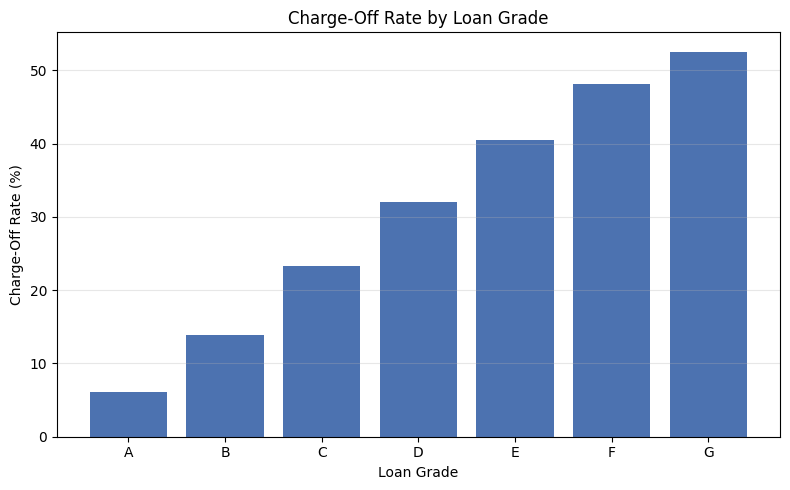

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(grade_summary.index, grade_summary['charge_off_rate'], color='#4C72B0')
ax.set_xlabel('Loan Grade')
ax.set_ylabel('Charge-Off Rate (%)')
ax.set_title('Charge-Off Rate by Loan Grade')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.2 — Loan Purpose

**Finding:** `small_business` is the riskiest purpose (31.34%), `car` the safest
(15.90%) among purposes with reliable sample sizes. `debt_consolidation` dominates
volume (58% of the dataset).

**Data quality note:** `wedding` (15 loans) and `educational` (1 loan) were excluded —
sample sizes too small to produce a statistically meaningful rate. A minimum threshold
of 100 loans per category was applied.

In [14]:
purpose_summary = df.groupby('purpose').agg(
    total_loans=('id', 'count'),
    charge_off_rate=('is_charged_off', 'mean')
)
purpose_summary['charge_off_rate'] = (purpose_summary['charge_off_rate'] * 100).round(2)

min_sample_size = 100
purpose_filtered = purpose_summary[purpose_summary['total_loans'] >= min_sample_size]
print(purpose_filtered.sort_values('charge_off_rate', ascending=False))

                    total_loans  charge_off_rate
purpose                                         
small_business            10826            31.33
renewable_energy            707            25.32
moving                     7831            24.80
house                      5766            23.47
medical                   13309            22.64
debt_consolidation       649386            22.09
other                     64800            21.62
major_purchase            23538            20.32
vacation                   7757            19.74
home_improvement          74053            18.51
credit_card              246743            17.73
car                       11071            15.90


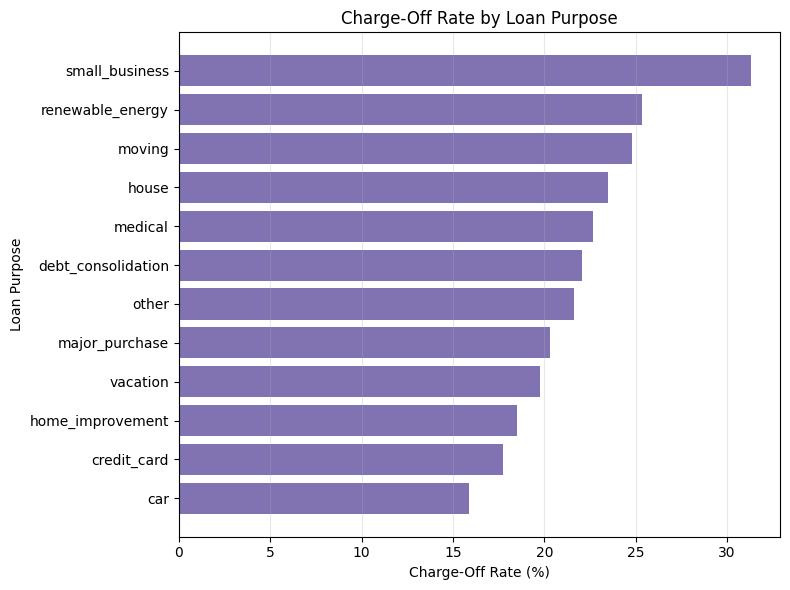

In [15]:
purpose_sorted = purpose_filtered.sort_values('charge_off_rate', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(purpose_sorted.index, purpose_sorted['charge_off_rate'], color='#8172B2')
ax.set_xlabel('Charge-Off Rate (%)')
ax.set_ylabel('Loan Purpose')
ax.set_title('Charge-Off Rate by Loan Purpose')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.3 — Vintage (Issue Year) Analysis

**Finding:** Charge-off rate rose from 18.45% (2014) to ~23% (2016–2017), suggesting
underwriting standards loosened or borrower quality shifted over this period.

**Important caveat — right-censoring bias:** The apparent drop in 2018 (15.76%) is
**not** real risk improvement. Since we only kept *resolved* loans and the data
snapshot ends in 2018Q4, most 2018 loans simply haven't had time to default yet
(typical 36–60 month terms) — only unusually fast payoffs or very early defaults show
as "resolved" for that cohort. 2018 should be treated as an immature, unreliable data
point, not a real trend continuation.

In [16]:
vintage_summary = df.groupby('issue_year').agg(
    total_loans=('id', 'count'),
    charge_off_rate=('is_charged_off', 'mean')
)
vintage_summary['charge_off_rate'] = (vintage_summary['charge_off_rate'] * 100).round(2)
print(vintage_summary.sort_index())

            total_loans  charge_off_rate
issue_year                              
2014.0           222988            18.45
2015.0           375382            20.18
2016.0           292800            23.29
2017.0           168701            23.12
2018.0            55932            15.74


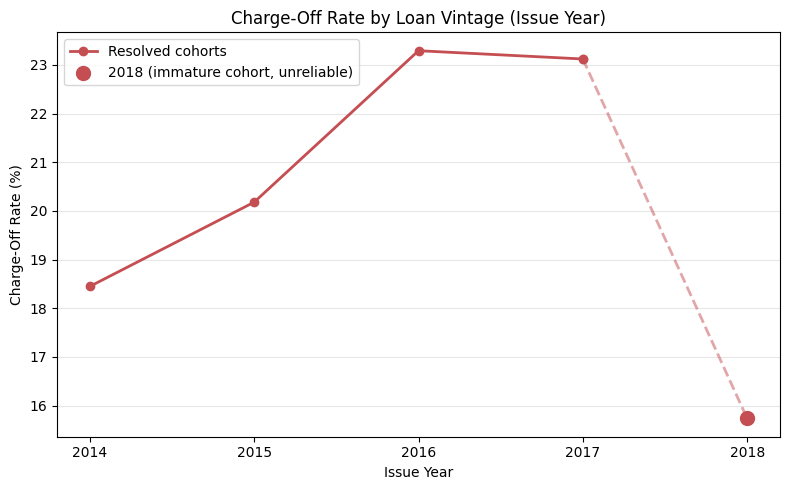

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
years = vintage_summary.index.astype(int)
rates = vintage_summary['charge_off_rate']

ax.plot(years[:-1], rates.iloc[:-1], marker='o', color='#C44E52', linewidth=2, label='Resolved cohorts')
ax.plot(years[-2:], rates.iloc[-2:], marker='o', color='#C44E52', linewidth=2, linestyle='--', alpha=0.5)
ax.scatter(years[-1], rates.iloc[-1], color='#C44E52', s=100, zorder=5, label='2018 (immature cohort, unreliable)')

ax.set_xlabel('Issue Year')
ax.set_ylabel('Charge-Off Rate (%)')
ax.set_title('Charge-Off Rate by Loan Vintage (Issue Year)')
ax.set_xticks(years)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.4 — Geography (State)

**Finding:** Charge-off rate ranges from ~14% (Maine) to ~26% (Mississippi). Riskier
states cluster in the South; safer states skew toward higher-income regions.

**Notable anomaly:** New York (89,698 loans — a large, reliable sample) shows an
elevated 23.30% charge-off rate. Follow-up analysis (below, §5) found this is **not**
explained by grade mix or purpose mix — NY's distribution across both is nearly
identical to the national average — suggesting unobserved regional factors (e.g., cost
of living) are at play.

In [18]:
state_summary = df.groupby('addr_state').agg(
    total_loans=('id', 'count'),
    charge_off_rate=('is_charged_off', 'mean')
)
state_summary['charge_off_rate'] = (state_summary['charge_off_rate'] * 100).round(2)

min_sample_size = 100
state_filtered = state_summary[state_summary['total_loans'] >= min_sample_size]

print("Top 10 riskiest states:")
print(state_filtered.sort_values('charge_off_rate', ascending=False).head(10))
print("\nTop 10 safest states:")
print(state_filtered.sort_values('charge_off_rate', ascending=True).head(10))

Top 10 riskiest states:
            total_loans  charge_off_rate
addr_state                              
MS                 6557            26.12
AR                 8361            25.58
NE                 3571            25.06
AL                13799            24.80
OK                10277            24.74
LA                12765            24.58
NY                89676            23.30
NV                16967            22.51
NM                 6142            22.39
MD                25860            22.37

Top 10 safest states:
            total_loans  charge_off_rate
addr_state                              
ME                 2024            13.88
VT                 2290            14.06
OR                13368            14.50
DC                 2690            14.50
NH                 5378            15.12
WA                23786            16.03
CO                24880            16.06
WV                 3786            16.67
SC                13372            16.76
UT        

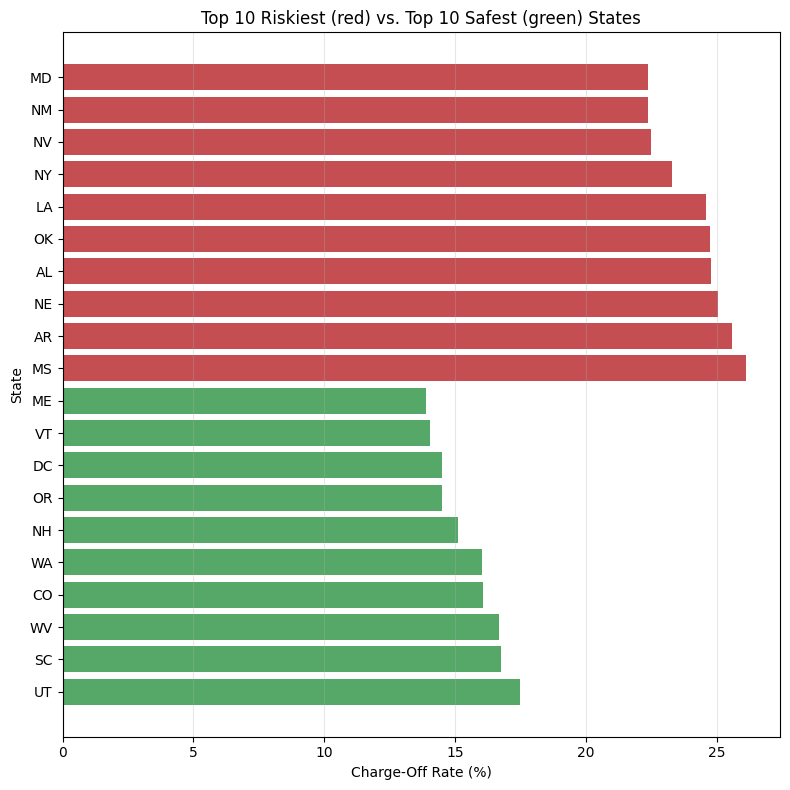

In [19]:
top10_risky = state_filtered.sort_values('charge_off_rate', ascending=False).head(10)
top10_safe = state_filtered.sort_values('charge_off_rate', ascending=True).head(10)

combined = pd.concat([top10_safe.sort_values('charge_off_rate', ascending=False), top10_risky.sort_values('charge_off_rate', ascending=False)])
colors = ['#55A868'] * 10 + ['#C44E52'] * 10

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(combined.index, combined['charge_off_rate'], color=colors)
ax.set_xlabel('Charge-Off Rate (%)')
ax.set_ylabel('State')
ax.set_title('Top 10 Riskiest (red) vs. Top 10 Safest (green) States')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

#### NY Anomaly Follow-Up: Grade & Purpose Mix Check

Testing whether NY's elevated risk is explained by its borrowers getting riskier
grades or purposes than average. **Result: no** — NY's mix is nearly identical to the
overall population on both dimensions, meaning something outside these two variables
(and outside this dataset) is driving the gap.

In [20]:
ny_grade_mix = df[df['addr_state'] == 'NY']['grade'].value_counts(normalize=True).sort_index() * 100
all_grade_mix = df['grade'].value_counts(normalize=True).sort_index() * 100

comparison = pd.DataFrame({'NY_pct': ny_grade_mix.round(2), 'All_States_pct': all_grade_mix.round(2)})
print(comparison)

       NY_pct  All_States_pct
grade                        
A       16.79           17.59
B       28.22           28.48
C       29.23           28.95
D       15.50           15.00
E        7.16            7.03
F        2.34            2.26
G        0.75            0.69


In [21]:
ny_purpose_mix = df[df['addr_state'] == 'NY']['purpose'].value_counts(normalize=True).sort_index() * 100
all_purpose_mix = df['purpose'].value_counts(normalize=True).sort_index() * 100

comparison_purpose = pd.DataFrame({'NY_pct': ny_purpose_mix.round(2), 'All_States_pct': all_purpose_mix.round(2)})
print(comparison_purpose)

                    NY_pct  All_States_pct
purpose                                   
car                   0.88            0.99
credit_card          23.22           22.11
debt_consolidation   55.36           58.20
educational            NaN            0.00
home_improvement      6.09            6.64
house                 0.61            0.52
major_purchase        2.25            2.11
medical               0.98            1.19
moving                1.17            0.70
other                 7.55            5.81
renewable_energy      0.08            0.06
small_business        0.95            0.97
vacation              0.85            0.70
wedding                NaN            0.00


### 4.5 — Debt-to-Income (DTI) Bands

**Finding:** Charge-off rate rises steadily with DTI, from 15.63% (0-10%) to 31.14%
(40-60%). The apparent dip in the highest band (60-100%, 29.75%) is based on a small
sample (1,180 loans) and is likely noise, not a genuine reversal.

In [22]:
bins = [0, 10, 20, 30, 40, 60, 100]
labels = ['0-10', '10-20', '20-30', '30-40', '40-60', '60-100']

df['dti_band'] = pd.cut(df['dti'], bins=bins, labels=labels, include_lowest=True)

dti_summary = df.groupby('dti_band', observed=True).agg(
    total_loans=('id', 'count'),
    charge_off_rate=('is_charged_off', 'mean')
)
dti_summary['charge_off_rate'] = (dti_summary['charge_off_rate'] * 100).round(2)
print(dti_summary)

          total_loans  charge_off_rate
dti_band                              
0-10           195672            15.63
10-20          458192            18.51
20-30          343696            23.91
30-40          112012            29.83
40-60            5051            31.14
60-100           1180            29.75


### 4.6 — FICO Score Bands

**Finding:** Strongest single-variable relationship found — charge-off rate falls from
26.09% (660-680) to 8.79% (760+), roughly a 3x spread, cleanly monotonic across all
bands.

**Note:** Minimum FICO in the dataset is 662, not the theoretical 300 floor — this
reflects LendingClub's own underwriting minimum (~660), not a data quality issue.

In [23]:
df['fico_score'] = (df['fico_range_low'] + df['fico_range_high']) / 2
print(df['fico_score'].describe())

count    1.115803e+06
mean     6.973966e+02
std      3.179551e+01
min      6.620000e+02
25%      6.720000e+02
50%      6.920000e+02
75%      7.120000e+02
max      8.475000e+02
Name: fico_score, dtype: float64


In [24]:
bins = [660, 680, 700, 720, 740, 760, 850]
labels = ['660-680', '680-700', '700-720', '720-740', '740-760', '760+']

df['fico_band'] = pd.cut(df['fico_score'], bins=bins, labels=labels, include_lowest=True)

fico_summary = df.groupby('fico_band', observed=True).agg(
    total_loans=('id', 'count'),
    charge_off_rate=('is_charged_off', 'mean')
)
fico_summary['charge_off_rate'] = (fico_summary['charge_off_rate'] * 100).round(2)
print(fico_summary)

           total_loans  charge_off_rate
fico_band                              
660-680         396710            26.09
680-700         296204            22.37
700-720         199746            18.09
720-740         106951            14.31
740-760          54126            11.60
760+             62066             8.79


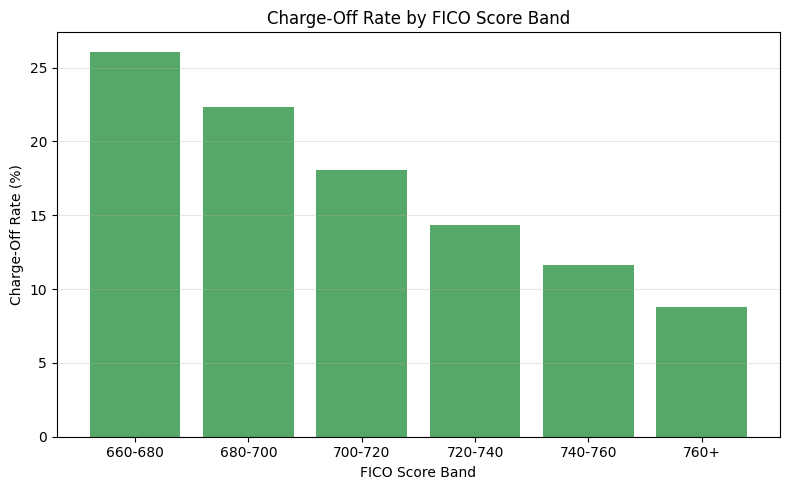

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(fico_summary.index, fico_summary['charge_off_rate'], color='#55A868')
ax.set_xlabel('FICO Score Band')
ax.set_ylabel('Charge-Off Rate (%)')
ax.set_title('Charge-Off Rate by FICO Score Band')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.7 — Credit History Length

**Finding:** A real but comparatively weak predictor — charge-off rate falls from
25.23% (0-5 years) to ~18-19% for longer-history borrowers, a much smaller spread than
grade or FICO. The trend also flattens/slightly reverses at 30+ years, likely within
noise given smaller sample size there. Excluded from the risk segmentation below since
it earns less analytical weight than grade, FICO, and DTI.

In [26]:
df['earliest_cr_line_parsed'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y', errors='coerce')
df['earliest_cr_year'] = df['earliest_cr_line_parsed'].dt.year
df['credit_history_years'] = df['issue_year'] - df['earliest_cr_year']

print(df['credit_history_years'].describe())

count    1.115803e+06
mean     1.650086e+01
std      7.584501e+00
min      3.000000e+00
25%      1.100000e+01
50%      1.500000e+01
75%      2.000000e+01
max      8.300000e+01
Name: credit_history_years, dtype: float64


In [27]:
bins = [0, 5, 10, 15, 20, 30, 100]
labels = ['0-5', '5-10', '10-15', '15-20', '20-30', '30+']

df['credit_history_band'] = pd.cut(df['credit_history_years'], bins=bins, labels=labels, include_lowest=True)

history_summary = df.groupby('credit_history_band', observed=True).agg(
    total_loans=('id', 'count'),
    charge_off_rate=('is_charged_off', 'mean')
)
history_summary['charge_off_rate'] = (history_summary['charge_off_rate'] * 100).round(2)
print(history_summary)

                     total_loans  charge_off_rate
credit_history_band                              
0-5                        39562            25.23
5-10                      175619            23.18
10-15                     379042            21.61
15-20                     248800            19.88
20-30                     210651            18.62
30+                        62129            18.69


## Phase 5: Multi-Factor Analysis — Grade x DTI Interaction

**Question:** Does DTI still predict risk once grade is already known, or is grade
already capturing everything DTI would tell us?

**Finding:** DTI matters *within every single grade*. Grade A ranges from 4.94%
(lowest DTI) to 10.87% (highest DTI) — more than doubling. The same widening pattern
holds all the way to Grade G (47.47% → 69.23%). This proves DTI provides risk
information beyond what grade alone captures — grade should not be relied on in
isolation.

In [28]:
pivot = df.pivot_table(
    index='grade',
    columns='dti_band',
    values='is_charged_off',
    aggfunc='mean',
    observed=True
)
pivot = (pivot * 100).round(2)
print(pivot)

dti_band   0-10  10-20  20-30  30-40  40-60  60-100
grade                                              
A          4.94   5.67   7.67   8.48   9.38   10.87
B         11.75  13.24  15.76  16.35  14.83   16.35
C         20.07  21.86  25.56  26.41  25.75   31.74
D         27.16  30.08  33.80  36.19  33.28   33.33
E         32.84  37.79  42.59  46.13  43.81   46.39
F         39.01  44.93  49.79  55.55  55.30   55.88
G         47.47  49.48  53.33  58.18  62.34   69.23


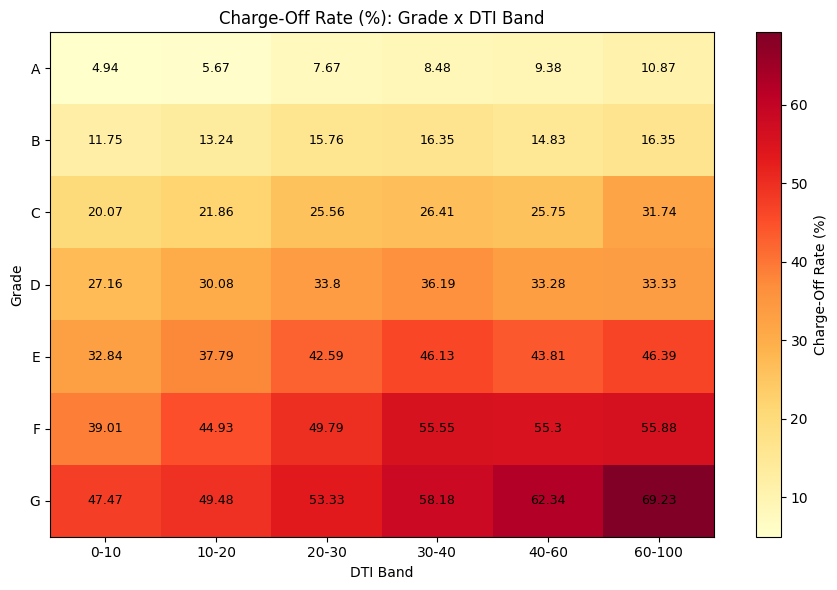

In [29]:
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('DTI Band')
ax.set_ylabel('Grade')
ax.set_title('Charge-Off Rate (%): Grade x DTI Band')

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, pivot.values[i, j], ha='center', va='center', color='black', fontsize=9)

plt.colorbar(im, ax=ax, label='Charge-Off Rate (%)')
plt.tight_layout()
plt.show()

## Phase 6: Custom Risk Segmentation

**Approach:** Built a transparent, explainable point-based risk score (no black-box
model) combining the three strongest predictors identified above, weighted by their
demonstrated predictive strength:

| Factor | Points | Weight rationale |
|---|---|---|
| Grade (A→G) | 0–6 | Strongest single predictor (6% → 53% spread) |
| FICO band | 0–5 | Second strongest (9% → 26% spread) |
| DTI band | 0–5 | Proven to add signal *beyond* grade (§5) |

Total score (0–16) bucketed into three business-friendly tiers: **Low Risk** (0–4),
**Medium Risk** (5–9), **High Risk** (10–16). Credit history length was deliberately
excluded — it earned a weak predictor rating in §4.7 and a good segmentation model
should only use variables that earn their place.

**Validation result:** Low Risk = 8.09% charge-off, Medium = 20.73%, High = 40.75% —
a clean ~5x spread between tiers, confirming the segmentation genuinely separates risk.

In [30]:
grade_points = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6}
fico_points = {'760+': 0, '740-760': 1, '720-740': 2, '700-720': 3, '680-700': 4, '660-680': 5}
dti_points = {'0-10': 0, '10-20': 1, '20-30': 2, '30-40': 3, '40-60': 4, '60-100': 5}

df['grade_pts'] = df['grade'].map(grade_points).astype(int)
df['fico_pts'] = df['fico_band'].astype(str).map(fico_points).astype(int)
df['dti_pts'] = df['dti_band'].astype(str).map(dti_points).astype(int)

df['risk_score'] = df['grade_pts'] + df['fico_pts'] + df['dti_pts']

def risk_tier(score):
    if score <= 4:
        return 'Low Risk'
    elif score <= 9:
        return 'Medium Risk'
    else:
        return 'High Risk'

df['risk_tier'] = df['risk_score'].apply(risk_tier)

tier_summary = df.groupby('risk_tier').agg(
    total_loans=('id', 'count'),
    charge_off_rate=('is_charged_off', 'mean')
)
tier_summary['charge_off_rate'] = (tier_summary['charge_off_rate'] * 100).round(2)
print(tier_summary.reindex(['Low Risk', 'Medium Risk', 'High Risk']))

             total_loans  charge_off_rate
risk_tier                                
Low Risk          212755             8.09
Medium Risk       760736            20.73
High Risk         142312            40.75


## Phase 7: Approval Funnel — Accepted vs. Rejected Comparison

Bringing in LendingClub's rejected-applications file (2014–2018, filtered from the full
2007–2018 history) to understand approval criteria and calculate an overall approval
rate.

In [31]:
rejected_sample = pd.read_csv('/content/rejected_2007_to_2018Q4.csv.gz', nrows=5, low_memory=False)
print(rejected_sample.shape)
print(rejected_sample.columns.tolist())

(5, 9)
['Amount Requested', 'Application Date', 'Loan Title', 'Risk_Score', 'Debt-To-Income Ratio', 'Zip Code', 'State', 'Employment Length', 'Policy Code']


In [32]:
chunk_size = 500_000
rejected_chunks = []

reader = pd.read_csv('/content/rejected_2007_to_2018Q4.csv.gz', chunksize=chunk_size, low_memory=False)

for i, chunk in enumerate(reader):
    chunk['app_year'] = pd.to_datetime(chunk['Application Date'], errors='coerce').dt.year
    mask = chunk['app_year'].between(2014, 2018)
    rejected_chunks.append(chunk[mask])
    if (i + 1) % 5 == 0:
        print(f"Processed chunk {i+1}...")

rejected = pd.concat(rejected_chunks, ignore_index=True)
print(f"\nTOTAL rejected loans 2014-2018: {len(rejected):,}")
print(rejected.shape)

Processed chunk 5...
Processed chunk 10...
Processed chunk 15...
Processed chunk 20...
Processed chunk 25...
Processed chunk 30...
Processed chunk 35...
Processed chunk 40...
Processed chunk 45...
Processed chunk 50...
Processed chunk 55...

TOTAL rejected loans 2014-2018: 26,132,308
(26132308, 10)


### 7.1 — Overall Approval Rate

**Finding: 7.21% overall approval rate.** LendingClub approved roughly 2.03M of 28.16M
total applications (2014–2018) — a highly selective platform, not a lender that
approves most applicants.

In [33]:
chunk_size = 200_000
total_accepted_2014_2018 = 0

reader = pd.read_csv('/content/accepted_2007_to_2018Q4.csv.gz', chunksize=chunk_size, low_memory=False, usecols=['issue_d'])

for chunk in reader:
    chunk['issue_year'] = pd.to_datetime(chunk['issue_d'], format='%b-%Y', errors='coerce').dt.year
    total_accepted_2014_2018 += chunk['issue_year'].between(2014, 2018).sum()

print(f"Total accepted loans 2014-2018 (all statuses): {total_accepted_2014_2018:,}")

total_rejected_2014_2018 = len(rejected)
overall_pool = total_accepted_2014_2018 + total_rejected_2014_2018
approval_rate = (total_accepted_2014_2018 / overall_pool) * 100

print(f"Total rejected loans 2014-2018: {total_rejected_2014_2018:,}")
print(f"Overall approval rate: {approval_rate:.2f}%")

Total accepted loans 2014-2018 (all statuses): 2,029,952
Total rejected loans 2014-2018: 26,132,308
Overall approval rate: 7.21%


### 7.2 — DTI: Accepted vs. Rejected

**Data quality note:** Rejected applications' DTI field is raw/unvalidated
(self-reported, never underwritten) — contained extreme outliers up to 7.3 million
percent. Cleaned using the same 0-100% threshold applied to accepted loans, dropping
~1.94M garbage rows (7.4% of rejected applications).

**Finding:** Rejected applicants average 26.94% DTI vs. accepted's 18.55% — a real
~8-point gap, but with wide overlap between the two distributions (accepted's 75th
percentile is close to rejected's median). DTI is a real factor in rejection, but not
a hard cutoff.

In [34]:
rejected['dti_clean'] = rejected['Debt-To-Income Ratio'].str.rstrip('%').astype(float)

print("Accepted loans DTI:")
print(df['dti'].describe())
print("\nRejected applications DTI (raw, unvalidated):")
print(rejected['dti_clean'].describe())

Accepted loans DTI:
count    1.115803e+06
mean     1.854942e+01
std      8.841433e+00
min      0.000000e+00
25%      1.204000e+01
50%      1.794000e+01
75%      2.455000e+01
max      1.000000e+02
Name: dti, dtype: float64

Rejected applications DTI (raw, unvalidated):
count    2.613231e+07
mean     1.181856e+02
std      3.087848e+03
min     -1.000000e+00
25%      8.190000e+00
50%      2.015000e+01
75%      3.697000e+01
max      7.374826e+06
Name: dti_clean, dtype: float64


In [35]:
rejected_clean_dti = rejected[(rejected['dti_clean'] >= 0) & (rejected['dti_clean'] <= 100)]

print(f"Rejected rows before DTI cleanup: {len(rejected):,}")
print(f"Rejected rows after DTI cleanup: {len(rejected_clean_dti):,}")
print(f"Rows dropped as garbage/outliers: {len(rejected) - len(rejected_clean_dti):,}")

print("\nAccepted loans DTI (cleaned):")
print(df['dti'].describe())
print("\nRejected applications DTI (cleaned):")
print(rejected_clean_dti['dti_clean'].describe())

Rejected rows before DTI cleanup: 26,132,308
Rejected rows after DTI cleanup: 24,191,792
Rows dropped as garbage/outliers: 1,940,516

Accepted loans DTI (cleaned):
count    1.115803e+06
mean     1.854942e+01
std      8.841433e+00
min      0.000000e+00
25%      1.204000e+01
50%      1.794000e+01
75%      2.455000e+01
max      1.000000e+02
Name: dti, dtype: float64

Rejected applications DTI (cleaned):
count    2.419179e+07
mean     2.694363e+01
std      2.489203e+01
min      0.000000e+00
25%      9.540000e+00
50%      2.054000e+01
75%      3.598000e+01
max      1.000000e+02
Name: dti_clean, dtype: float64


### 7.3 — Credit Score: Accepted vs. Rejected

**Data quality note:** 70.6% of rejected applications have no `Risk_Score` recorded —
likely because many rejections happen before a credit pull occurs (incomplete
applications, early-stage rejections). This finding applies only to the ~29% of
rejected applicants who received a credit check.

**Finding:** Rejected applicants (with a score) average 633 vs. accepted's 697 — a
64-point gap, a much stronger separator than DTI, though still with meaningful overlap
in the 650-700 range.

In [36]:
print("Accepted loans FICO score:")
print(df['fico_score'].describe())
print("\nRejected applications Risk_Score:")
print(rejected['Risk_Score'].describe())

Accepted loans FICO score:
count    1.115803e+06
mean     6.973966e+02
std      3.179551e+01
min      6.620000e+02
25%      6.720000e+02
50%      6.920000e+02
75%      7.120000e+02
max      8.475000e+02
Name: fico_score, dtype: float64

Rejected applications Risk_Score:
count    7.682429e+06
mean     6.333973e+02
std      6.539020e+01
min      3.000000e+02
25%      5.920000e+02
50%      6.350000e+02
75%      6.730000e+02
max      9.900000e+02
Name: Risk_Score, dtype: float64


In [37]:
missing_riskscore = rejected['Risk_Score'].isnull().sum()
missing_pct = (missing_riskscore / len(rejected)) * 100
print(f"Rejected applications missing Risk_Score: {missing_riskscore:,} ({missing_pct:.1f}%)")

Rejected applications missing Risk_Score: 18,449,879 (70.6%)


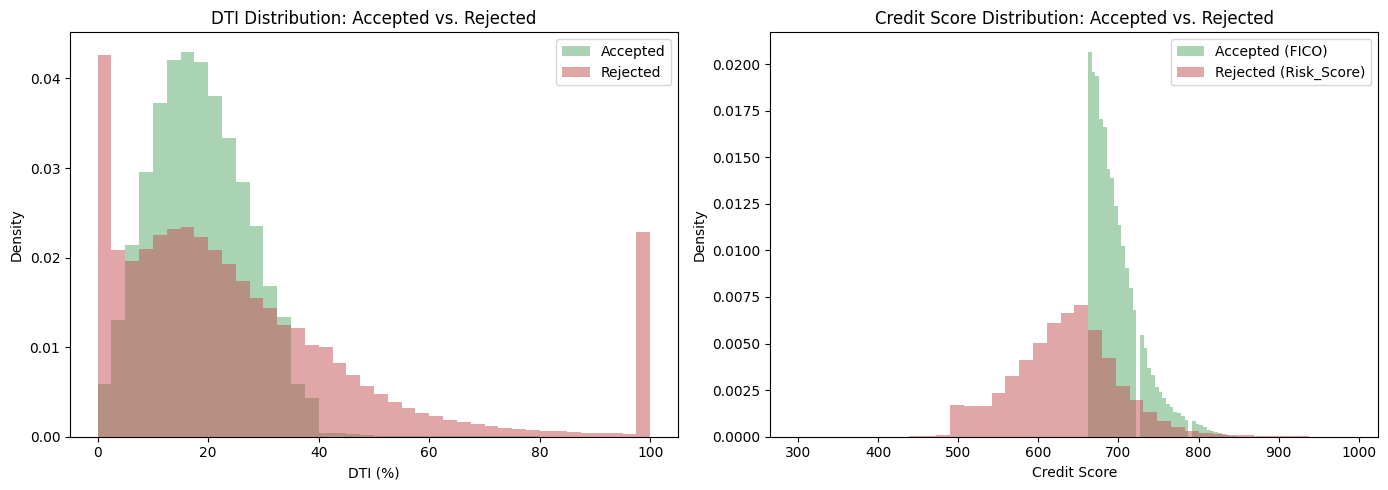

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['dti'], bins=40, alpha=0.5, label='Accepted', color='#55A868', density=True)
axes[0].hist(rejected_clean_dti['dti_clean'], bins=40, alpha=0.5, label='Rejected', color='#C44E52', density=True)
axes[0].set_xlabel('DTI (%)')
axes[0].set_ylabel('Density')
axes[0].set_title('DTI Distribution: Accepted vs. Rejected')
axes[0].legend()

axes[1].hist(df['fico_score'], bins=40, alpha=0.5, label='Accepted (FICO)', color='#55A868', density=True)
axes[1].hist(rejected['Risk_Score'].dropna(), bins=40, alpha=0.5, label='Rejected (Risk_Score)', color='#C44E52', density=True)
axes[1].set_xlabel('Credit Score')
axes[1].set_ylabel('Density')
axes[1].set_title('Credit Score Distribution: Accepted vs. Rejected')
axes[1].legend()

plt.tight_layout()
plt.show()

## Phase 8: Supplementary Checks — Income & Loan Amount

Basic distribution checks on two fundamental loan variables not yet examined
individually.

**Finding — loan amount:** Clean range ($1,000-$40,000, matching LendingClub's real
lending caps). Distribution shows clear "round-number bias" — spikes at $5K, $10K,
$15K, $20K, $35K — a real observed borrower behavior (requesting round figures) rather
than noise.

**Finding — annual income:** Right-skewed as expected (median $65,000). A small number
of extreme outliers exist (max ~$11M, likely unverified self-reports) — 1,528 rows
above $500K (0.14%). Too rare to affect groupby-based analyses, but capped at $250K for
visualization only (underlying data left untouched).

In [39]:
print("Annual Income:")
print(df['annual_inc'].describe())
print("\nLoan Amount:")
print(df['loan_amnt'].describe())

Annual Income:
count    1.115803e+06
mean     7.722505e+04
std      7.262375e+04
min      4.300000e+02
25%      4.600000e+04
50%      6.500000e+04
75%      9.200000e+04
max      1.099920e+07
Name: annual_inc, dtype: float64

Loan Amount:
count    1.115803e+06
mean     1.454227e+04
std      8.830413e+03
min      1.000000e+03
25%      8.000000e+03
50%      1.200000e+04
75%      2.000000e+04
max      4.000000e+04
Name: loan_amnt, dtype: float64


In [40]:
print("Income above $500K:", (df['annual_inc'] > 500_000).sum())
print("Income above $1M:", (df['annual_inc'] > 1_000_000).sum())
print("Income above $2M:", (df['annual_inc'] > 2_000_000).sum())

Income above $500K: 1528
Income above $1M: 257
Income above $2M: 88


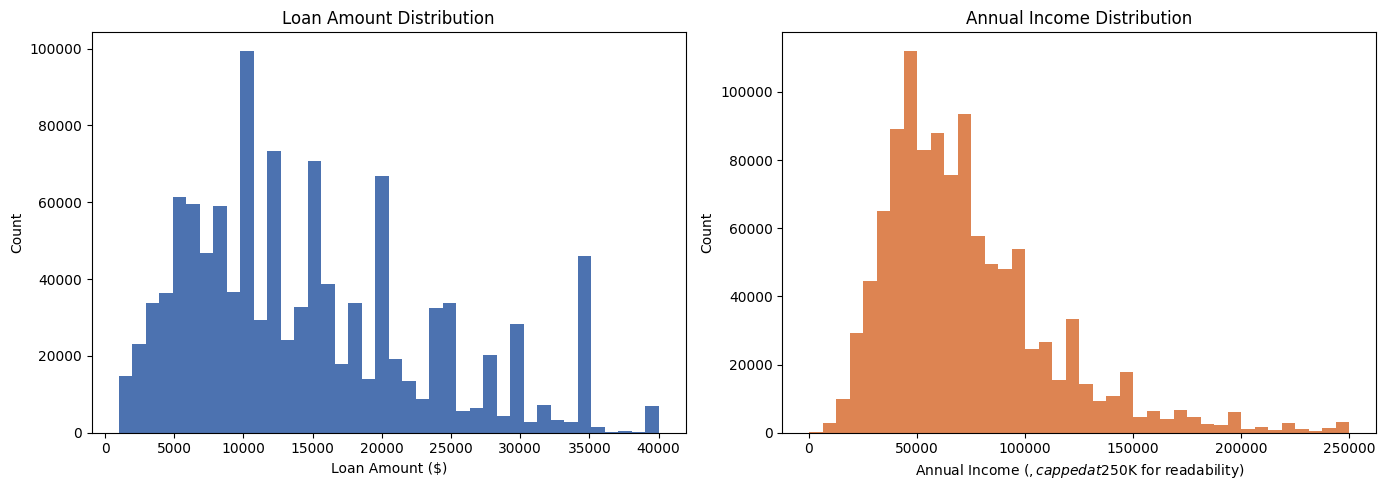

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['loan_amnt'], bins=40, color='#4C72B0')
axes[0].set_xlabel('Loan Amount ($)')
axes[0].set_ylabel('Count')
axes[0].set_title('Loan Amount Distribution')

income_for_chart = df['annual_inc'][df['annual_inc'] <= 250_000]
axes[1].hist(income_for_chart, bins=40, color='#DD8452')
axes[1].set_xlabel(r'Annual Income ($, capped at $250K for readability)')
axes[1].set_ylabel('Count')
axes[1].set_title('Annual Income Distribution')

plt.tight_layout()
plt.show()

## Final: Save Working Datasets

Saving the fully cleaned, feature-engineered datasets for use in the Excel and Power BI
phases of this project.

**Note on scope:** A simple bonus predictive model (logistic regression) was considered
and deliberately excluded from this project — the manual, business-driven risk
segmentation above already provides a strong, fully explainable result appropriate for
a data analyst / business analyst portfolio, without the added complexity and risk of a
weakly-validated model.

In [42]:
df.to_csv('accepted_final.csv', index=False)
print("Accepted saved:", df.shape)

rejected_clean_dti.to_csv('rejected_final.csv', index=False)
print("Rejected saved:", rejected_clean_dti.shape)

Accepted saved: (1115803, 40)
Rejected saved: (24191792, 11)
